# 09 · Alert evaluation, false positives and workload
Evaluation population: held-out accounts (group 1) in test weeks 13-21. Ground truth = AMLSim typology label.
With a base rate near 9%, accuracy is meaningless (predicting 'nothing suspicious' would be about 91% accurate), so we report
precision, recall, false-positive rate, PR-AUC and alert volumes.

In [1]:
import sys, json, sqlite3
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import config
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
T = lambda name: pd.read_csv(config.TABLES_DIR / f"{name}.csv")
KM = json.loads((config.TABLES_DIR / "key_metrics.json").read_text())
con = sqlite3.connect(config.DB_PATH)
def show(fig_name, width=11):
    img = plt.imread(config.FIGURES_DIR / f"{fig_name}.png")
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w)); ax.imshow(img); ax.axis("off")
print("outputs loaded from", config.TABLES_DIR.relative_to(ROOT))

outputs loaded from outputs/tables


In [2]:
bc = T("baseline_comparison")
bc[["approach", "alerts", "alerts_per_week", "alerts_per_1000_tx", "alert_precision", "account_precision",
    "account_recall", "f1", "false_positive_accounts", "fpr_accounts", "tp", "fp", "fn", "tn"]]

,approach,alerts,alerts_per_week,alerts_per_1000_tx,alert_precision,account_precision,account_recall,f1,false_positive_accounts,fpr_accounts,tp,fp,fn,tn
0,B1 Amount threshold,488,54.2222,13.7144,0.1148,0.1311,0.0539,0.0764,305,0.0362,46,305,807,8119
1,B2 Amount + velocity,807,89.6667,22.6794,0.4064,0.3824,0.2438,0.2978,336,0.0399,208,336,645,8088
2,B3 Behavioural anomaly,367,40.7778,10.3139,0.6649,0.6022,0.1934,0.2928,109,0.0129,165,109,688,8315
3,B4 Network / AML patterns,973,108.1111,27.3445,0.3720,0.2441,0.1454,0.1822,384,0.0456,124,384,729,8040
4,B5a Integrated rules (>=2 families),316,35.1111,8.8806,0.7500,0.7079,0.1676,0.2711,59,0.0070,143,59,710,8365
5,B5b Integrated risk score (top 1%),215,23.8889,6.0422,0.8651,0.8571,0.1407,0.2417,20,0.0024,120,20,733,8404
6,ML1 Logistic regression (unconstrained),709,78.7778,19.9252,0.9845,0.9784,0.5838,0.7313,11,0.0013,498,11,355,8413
7,ML2 Gradient boosting,387,43.0000,10.8760,0.9793,0.9814,0.3716,0.5391,6,0.0007,317,6,536,8418
8,ML3 Isolation Forest (unsupervised),189,21.0000,5.3115,0.7037,0.5797,0.0469,0.0868,29,0.0034,40,29,813,8395


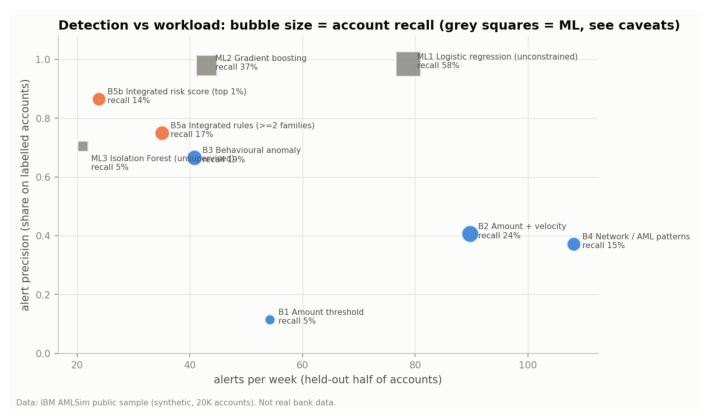

In [3]:
show("fig09_detection_workload_tradeoff", 10)

In [4]:
T("ranking_metrics")

,approach,roc_auc,pr_auc,base_rate,n_accounts,precision_top1pct,recall_top1pct,precision_top5pct,recall_top5pct,precision_top10pct,recall_top10pct,precision_top20pct,recall_top20pct
0,B1 Amount threshold,0.5554,0.1114,0.0919,9277,0.1505,0.0164,0.1250,0.0680,0.1261,0.1372,0.1164,0.2532
1,B2 Amount + velocity,0.7834,0.4450,0.0919,9277,0.7849,0.0856,0.6875,0.3740,0.4515,0.4912,0.2668,0.5803
2,B5a Integrated rules (>=2 families),0.7395,0.3660,0.0919,9277,0.6989,0.0762,0.5474,0.2978,0.3136,0.3411,0.2561,0.5569
3,B5b Integrated risk score (top 1%),0.7534,0.4573,0.0919,9277,0.8817,0.0961,0.6875,0.3740,0.4526,0.4924,0.2706,0.5885
4,ML1 Logistic regression (unconstrained),0.8470,0.7127,0.0919,9277,1.0000,0.1090,0.9828,0.5346,0.5959,0.6483,0.3245,0.7057
5,ML2 Gradient boosting,0.7997,0.5972,0.0919,9277,1.0000,0.1090,0.8362,0.4549,0.4978,0.5416,0.2895,0.6295
6,ML3 Isolation Forest (unsupervised),0.8086,0.3985,0.0919,9277,0.6022,0.0657,0.5431,0.2954,0.4612,0.5018,0.2976,0.6471


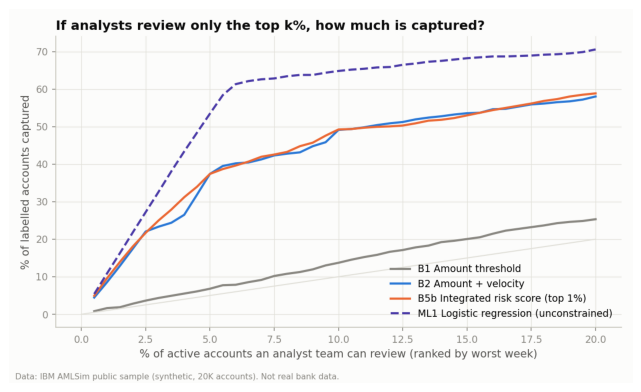

,decile,accounts,labelled,labelled_rate,share_of_all_labelled,cumulative_capture
0,1,928,420,0.4526,0.4924,0.4924
1,2,928,82,0.0884,0.0961,0.5885
2,3,927,56,0.0604,0.0657,0.6542
3,4,928,30,0.0323,0.0352,0.6893
4,5,928,54,0.0582,0.0633,0.7526
5,6,927,96,0.1036,0.1125,0.8652
6,7,928,13,0.0140,0.0152,0.8804
7,8,927,16,0.0173,0.0188,0.8992
8,9,928,22,0.0237,0.0258,0.9250
9,10,928,64,0.0690,0.0750,1.0000


In [5]:
show("fig10_topk_capture", 9)
T("risk_decile_performance")

### Threshold sensitivity

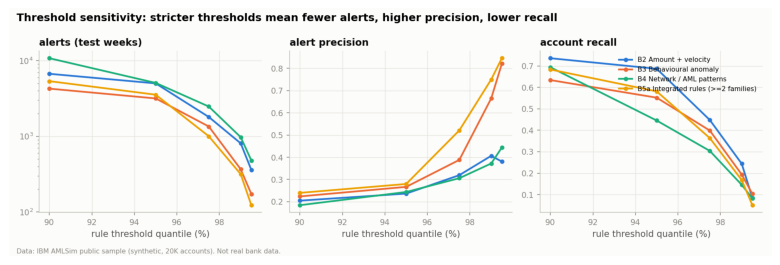

,approach,parameter,value,alerts,alert_precision,account_recall
0,B2 Amount + velocity,rule quantile,0.900,6681,0.2048,0.7362
1,B3 Behavioural anomaly,rule quantile,0.900,4255,0.2237,0.6342
2,B4 Network / AML patterns,rule quantile,0.900,10727,0.1843,0.6940
3,B5a Integrated rules (>=2 families),rule quantile,0.900,5342,0.2398,0.6835
4,B2 Amount + velocity,rule quantile,0.950,4994,0.2365,0.6870
5,B3 Behavioural anomaly,rule quantile,0.950,3160,0.2668,0.5522
6,B4 Network / AML patterns,rule quantile,0.950,5066,0.2438,0.4455
7,B5a Integrated rules (>=2 families),rule quantile,0.950,3539,0.2797,0.5815
8,B2 Amount + velocity,rule quantile,0.975,1797,0.3194,0.4478
9,B3 Behavioural anomaly,rule quantile,0.975,1345,0.3881,0.3986


In [6]:
show("fig11_threshold_sensitivity")
T("threshold_sensitivity")[["approach", "parameter", "value", "alerts", "alert_precision", "account_recall"]]

### Precision at realistic prevalence (projection)

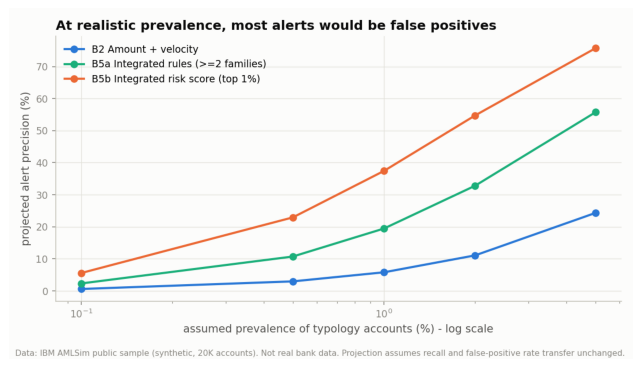

prevalence,0.001,0.005,0.01,0.02,0.05
approach,,,,,
B1 Amount threshold,0.001,0.007,0.015,0.030,0.073
B2 Amount + velocity,0.006,0.030,0.058,0.111,0.243
B3 Behavioural anomaly,0.015,0.070,0.131,0.234,0.440
B4 Network / AML patterns,0.003,0.016,0.031,0.061,0.144
B5a Integrated rules (>=2 families),0.023,0.107,0.195,0.328,0.557
B5b Integrated risk score (top 1%),0.056,0.229,0.374,0.547,0.757
ML1 Logistic regression (unconstrained),0.309,0.692,0.819,0.901,0.959
ML2 Gradient boosting,0.343,0.724,0.841,0.914,0.965
ML3 Isolation Forest (unsupervised),0.013,0.064,0.121,0.218,0.418


In [7]:
show("fig12_prevalence_projection", 9)
T("prevalence_projection").pivot_table(index="approach", columns="prevalence", values="projected_precision").round(3)

In [8]:
pd.read_csv(config.TABLES_DIR / "sql" / "q10_alert_workload_by_week_and_tier.csv")

,week,alerts,critical,high,medium,low,high_priority_pct,avg_score
0,5,53,5,12,20,16,32.1,99.53
1,6,48,3,10,13,22,27.1,99.48
2,7,71,8,6,21,36,19.7,99.45
3,8,158,13,37,48,60,31.6,99.51
4,9,130,15,25,36,54,30.8,99.49
5,10,106,14,22,31,39,34.0,99.52
6,11,101,10,24,26,41,33.7,99.51
7,12,117,10,21,40,46,26.5,99.49
8,13,80,6,23,23,28,36.3,99.52
9,14,92,8,15,34,35,25.0,99.50
